# *Matríz Condensada de un Pórtico Plano en X*

**`Realizado por:`** Grupo #4 | Dinámica.  
**`Pregrado:`** Ingeniería civil.     
**`Institución:`** Universidad Nacional de Colombia.  

---  
---  

### | *Datos iniciales*

In [1]:
import numpy as np

# === NODOS Y GRADOS DE LIBERTAD ===
nnod = 30                # Número de nodos (todos los del edificio y la base)
ngdl = 5+60              # Número total de grados de libertad (sólo 1 horizontal por piso y la base)
nc, nv = 24, 20          # Número de columnas y vigas
nelem = nc + nv


# Matriz de GDL: cada fila representa [ux, uy, rz] para cada nodo (los principales representan los dos horizontales de su piso)
gdl = np.array([
    [1, 6, 7],
    [1, 8, 9],
    [1, 10, 11],
    [1, 12, 13],
    [1, 14, 15],
    [1, 16, 17],
    
    [2, 18, 19],
    [2, 20, 21],
    [2, 22, 23],
    [2, 24, 25],
    [2, 26, 27],
    [2, 28, 29],
    
    [3, 30, 31],
    [3, 32, 33],
    [3, 34, 35],
    [3, 36, 37],
    [3, 38, 39],
    [3, 40, 41],
    
    [4, 42, 43],
    [4, 44, 45],
    [4, 46, 47],
    [4, 48, 49],
    [4, 50, 51],
    [4, 52, 53],
    
    [5, 54, 55],
    [5, 56, 57],
    [5, 58, 59],
    [5, 60, 61],
    [5, 62, 63],
    [5, 64, 65]                          # Chequear que se términe en la cantidad de GDL
]) 

p = np.array([2, 3, 4, 5]) - 1           # Horizontales sin contar el de la base
s = np.arange(18, 65+1) - 1              # Los demás sin contar los de la base (hasta el total+1)

# Coordenadas de los nodos (X, Y)        # nodos de derecha a izquierda, de abajo hacia arriba
coord = np.array([
    [0.0 ,  0.0],     # Nodo 1
    [5.1 ,  0.0],     # Nodo 2
    [10.2,  0.0],     # Nodo 3
    [15.3,  0.0],     # Nodo 4
    [20.4,  0.0],     # Nodo 5
    [25.5,  0.0],     # Nodo 6
    
    [0.0 ,  2.8],     # Nodo 7
    [5.1 ,  2.8],     # Nodo 8
    [10.2,  2.8],     # Nodo 9
    [15.3,  2.8],     # Nodo 10
    [20.4,  2.8],     # Nodo 11
    [25.5,  2.8],     # Nodo 12
    
    [0.0 ,  5.6],     # Nodo 13
    [5.1 ,  5.6],     # Nodo 14
    [10.2,  5.6],     # Nodo 15
    [15.3,  5.6],     # Nodo 16
    [20.4,  5.6],     # Nodo 17
    [25.5,  5.6],     # Nodo 18
    
    [0.0 ,  8.4],     # Nodo 19
    [5.1 ,  8.4],     # Nodo 20
    [10.2,  8.4],     # Nodo 21
    [15.3,  8.4],     # Nodo 22
    [20.4,  8.4],     # Nodo 23
    [25.5,  8.4],     # Nodo 24
    
    [0.0 ,  11.2],     # Nodo 25
    [5.1 ,  11.2],     # Nodo 26
    [10.2,  11.2],     # Nodo 27
    [15.3,  11.2],     # Nodo 28
    [20.4,  11.2],     # Nodo 29
    [25.5,  11.2],     # Nodo 30
])

# === ELEMENTOS ===
# Conectividad: (nodo_i, nodo_j)   # Primero columnas, luego vigas
elem = np.array([
    
    # Columnas
    
    [1, 7],
    [2, 8],
    [3, 9],
    [4, 10],
    [5, 11],
    [6, 12],
    
    [7, 13],
    [8, 14],
    [9, 15],
    [10, 16],
    [11, 17],
    [12, 18],
    
    [13, 19],
    [14, 20],
    [15, 21],
    [16, 22],
    [17, 23],
    [18, 24],
    
    [19, 25],
    [20, 26],
    [21, 27],
    [22, 28],
    [23, 29],
    [24, 30],
    
    
    # Vigas
    
    [7, 8],
    [8, 9],
    [9, 10],
    [10, 11],
    [11, 12],
    
    [13, 14],
    [14, 15],
    [15, 16],
    [16, 17],
    [17, 18],
    
    [19, 20],
    [20, 21],
    [21, 22],
    [22, 23],
    [23, 24],
    
    [25, 26],
    [26, 27],
    [27, 28],
    [28, 29],
    [29, 30]
]) - 1  # Restamos 1 para usar índices desde cero

# Propiedades de columnas y vigas
Ec, Ac, Ic = 4700*(21**0.5)*1000, 0.2,  (0.5*0.4**3)/12    # kPa , m², m⁴ Flexión de columnas en el eje y
Ev, Av, Iv = 4700*(21**0.5)*1000, 0.12, (0.3*0.4**3)/12

### | *Gráfico del pórtico*

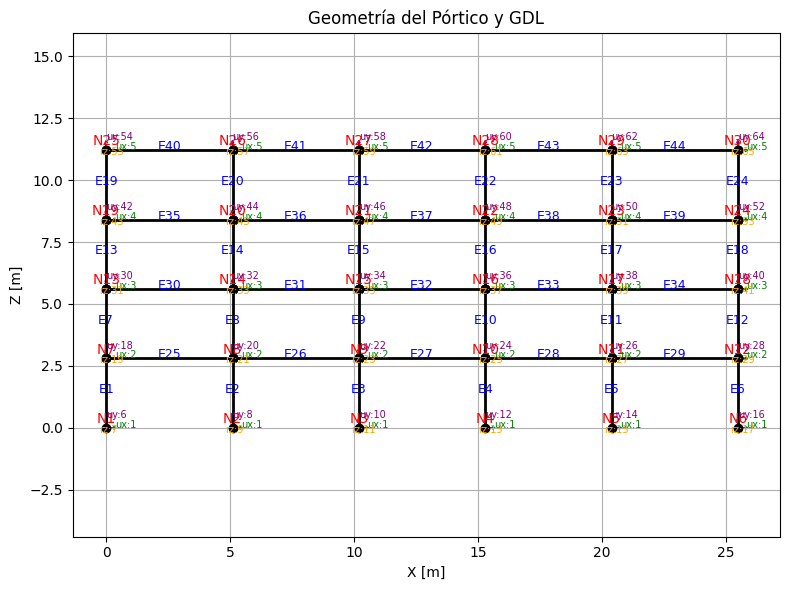

In [2]:
import matplotlib.pyplot as plt

def graficar_portico_con_gdl(coord, elem, gdl, numerar_nodos=True, mostrar_gdl=True):
    
    plt.figure(figsize=(8, 6))

    # Dibujar elementos
    for e, (ni, nj) in enumerate(elem):
        xi, yi = coord[ni]
        xj, yj = coord[nj]
        plt.plot([xi, xj], [yi, yj], 'k-o', linewidth=2, markersize=6)
        xm, ym = (xi + xj) / 2, (yi + yj) / 2
        plt.text(xm, ym, f"E{e+1}", color='blue', fontsize=9, ha='center')

    # Dibujar nodos y GDL
    for i, (x, y) in enumerate(coord):
        if numerar_nodos:
            plt.text(x, y + 0.2, f"N{i+1}", color='red', fontsize=10, ha='center')
        
        if mostrar_gdl:
            ux, uy, rz = gdl[i]
            # ux: flecha en X
            plt.arrow(x, y, 0.3, 0, head_width=0.1, head_length=0.1, fc='green', ec='green')
            plt.text(x + 0.35, y, f"ux:{ux}", color='green', fontsize=7)
            # uy: flecha en Y
            plt.arrow(x, y, 0, 0.3, head_width=0.1, head_length=0.1, fc='purple', ec='purple')
            plt.text(x, y + 0.4, f"uy:{uy}", color='purple', fontsize=7)
            # rz: rotación
            plt.text(x - 0.3, y - 0.2, f"rz:{rz}", color='orange', fontsize=7)

    plt.axis('equal')
    plt.xlabel("X [m]")
    plt.ylabel("Z [m]")
    plt.title("Geometría del Pórtico y GDL")
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
graficar_portico_con_gdl(coord, elem, gdl)

### | *Análisis Matricial*

In [3]:
# Inicialización
L = np.zeros(nelem)
eta = np.zeros(nelem)
mu = np.zeros(nelem)
K = np.zeros((ngdl, ngdl))
Ke = [None] * nelem

# Longitudes y directores
for e in range(nelem):
    ni, nj = elem[e]
    xi, yi = coord[ni]
    xj, yj = coord[nj]
    L[e] = np.sqrt((xj - xi)**2 + (yj - yi)**2)
    eta[e] = (xj - xi)/L[e]
    mu[e] = (yj - yi)/L[e]

# === COLUMNAS ===
for e in range(nc):
    E, A, I = Ec, Ac, Ic
    l = L[e]
    k = np.array([
        [ E*A/l,       0,            0,         -E*A/l,      0,            0],
        [ 0,     12*E*I/l**3,  6*E*I/l**2,      0,    -12*E*I/l**3,  6*E*I/l**2],
        [ 0,     6*E*I/l**2,   4*E*I/l,         0,     -6*E*I/l**2,  2*E*I/l],
        [-E*A/l,       0,            0,          E*A/l,      0,            0],
        [ 0,    -12*E*I/l**3, -6*E*I/l**2,      0,     12*E*I/l**3, -6*E*I/l**2],
        [ 0,     6*E*I/l**2,   2*E*I/l,         0,     -6*E*I/l**2,  4*E*I/l]
    ])
    
    T = np.block([
        [eta[e],   mu[e],   0,       0,       0,  0],
        [-mu[e],  eta[e],   0,       0,       0,  0],
        [0,            0,   1,       0,       0,  0],
        [0,            0,   0,  eta[e],   mu[e],  0],
        [0,            0,   0,  -mu[e],  eta[e],  0],
        [0,            0,   0,       0,       0,  1]
    ])
    
    Ke[e] = T.T @ k @ T
    dof = np.concatenate([gdl[elem[e,0]], gdl[elem[e,1]]]) - 1
    K[np.ix_(dof, dof)] += Ke[e]

# === VIGAS === (Versión corregida)
for e in range(nc, nelem):
    E, A, I = Ev, Av, Iv
    l = L[e]
    
    # Matriz de rigidez local reducida (solo flexión: uy y rz)
    k = np.array([
        [12*E*I/l**3,   6*E*I/l**2,  -12*E*I/l**3,   6*E*I/l**2],
        [6*E*I/l**2,    4*E*I/l,      -6*E*I/l**2,    2*E*I/l],
        [-12*E*I/l**3, -6*E*I/l**2,   12*E*I/l**3,   -6*E*I/l**2],
        [6*E*I/l**2,    2*E*I/l,      -6*E*I/l**2,    4*E*I/l]
    ])
    
    # Matriz de transformación reducida
    c = eta[e]
    T = np.array([
        [c, 0, 0, 0],
        [0, 1, 0, 0],
        [0, 0, c, 0],
        [0, 0, 0, 1]
    ])
    
    Ke[e] = T.T @ k @ T
    
    # CORRECCIÓN CLAVE: Definición correcta de GDL para vigas
    ni, nj = elem[e]
    dof = np.array([
        gdl[ni][1],  # uy nodo i
        gdl[ni][2],  # rz nodo i
        gdl[nj][1],  # uy nodo j
        gdl[nj][2]   # rz nodo j
    ]) - 1  # Convertimos a índices base 0
    
    K[np.ix_(dof, dof)] += Ke[e]

### | *Condensación*

In [4]:
Kpp = K[np.ix_(p, p)]
Kps = K[np.ix_(p, s)]
Ksp = K[np.ix_(s, p)]
Kss = K[np.ix_(s, s)]

Kc = Kpp - Kps@np.linalg.inv(Kss)@Ksp

Kct = (4*Kc)        # 4 Pórticos en este sentido

np.set_printoptions(precision=4, suppress=True)
print(f"Matriz de rigidez condensada kct en sentido X [kN/m]:")
print(Kct)  


Matriz de rigidez condensada kct en sentido X [kN/m]:
[[1290508.6224 -751281.8033  204343.8969  -29102.5151]
 [-751281.8033 1092225.8829 -694852.8885  152552.5426]
 [ 204343.8969 -694852.8885  979093.9482 -451738.6672]
 [ -29102.5151  152552.5426 -451738.6672  322911.6742]]


### | *Cálculo desplazamientos*

In [5]:
F = np.array([1000 , 2000 , 3000, 4000])       # 1 : Primer piso | 2 : Segundo piso ....
u = np.linalg.solve(Kc, F)*1000                       # Convertir a mm
for i, val in enumerate(u, 1):
    print(f"u[{i}] = {val:.6f} [mm]")

u[1] = 125.160356 [mm]
u[2] = 317.873444 [mm]
u[3] = 480.911311 [mm]
u[4] = 583.429863 [mm]


### | *Cálculo derivas*

In [6]:
hp = 2.8              # Altura entre pisos (en m)

for i in range(len(u)):
    if i == 0:
        deriva = u[i]/(hp*1000)  # primer piso respecto al suelo (0)
        print(f"Deriva entre suelo y piso {i+1} : {deriva:.6f} | en porcentaje: {deriva*100:.4f}%")
    else:
        deriva = (u[i] - u[i-1])/(hp*1000)
        print(f"Deriva entre piso {i} y piso {i+1}: {deriva:.6f} | en porcentaje: {deriva*100:.4f}%")

Deriva entre suelo y piso 1 : 0.044700 | en porcentaje: 4.4700%
Deriva entre piso 1 y piso 2: 0.068826 | en porcentaje: 6.8826%
Deriva entre piso 2 y piso 3: 0.058228 | en porcentaje: 5.8228%
Deriva entre piso 3 y piso 4: 0.036614 | en porcentaje: 3.6614%
